Checkpoint: /workspace/end2endgs/checkpoints/mip_ckpt/splat_ep1900.pt
  Epoch  : 1900,  K = 483952
  Volume loaded: (100, 647, 813), range [0.000, 1.000]
  PSNR = 33.49 dB


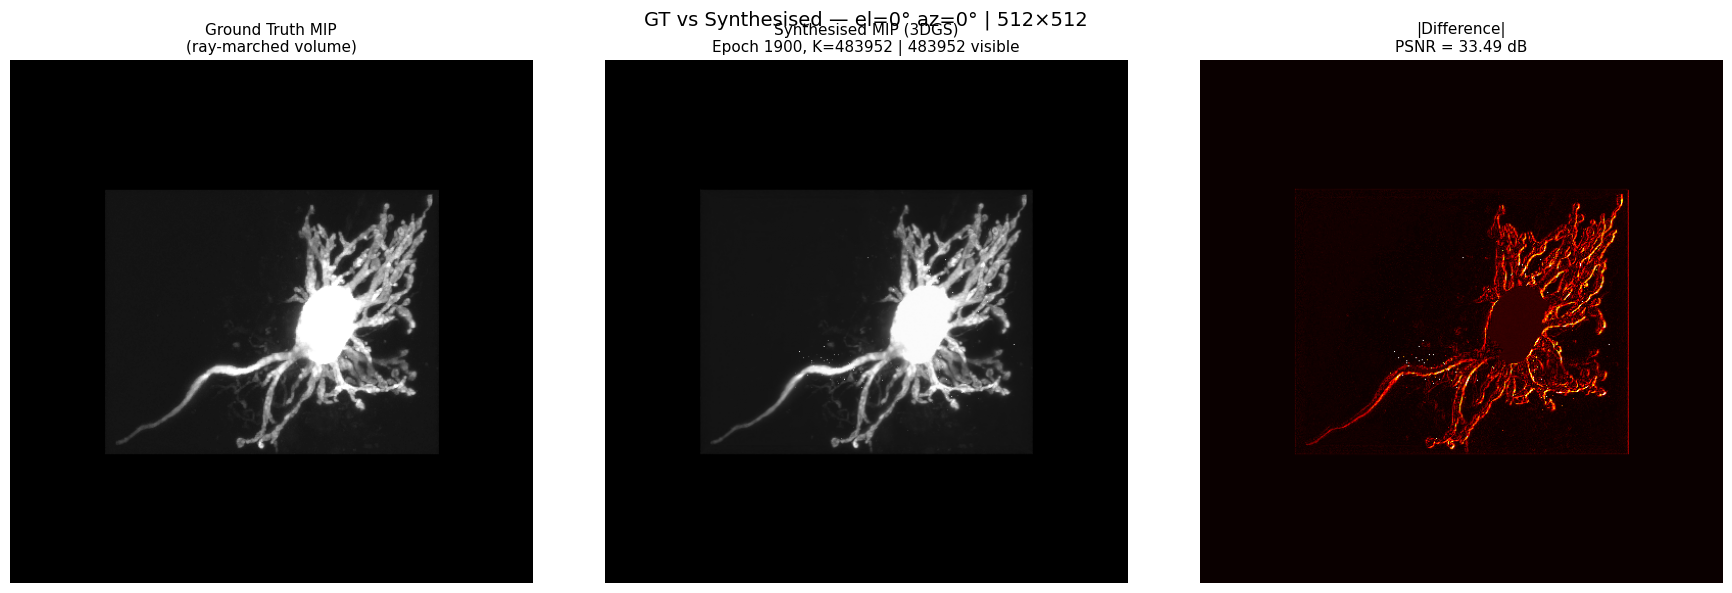

In [7]:
"""
Load trained 3DGS model and render synthesised MIP vs ground-truth MIP
from the same viewpoint.
"""
import sys, os, math
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath(".."))

from rendering import (
    Camera, GaussianParameters,
    compute_aspect_scales, apply_aspect_correction,
    render_mip_projection, render_gt_mip,
    load_volume, load_config, _orbit_pose,
    psnr_metric,
)

# ── 1. Load checkpoint ──────────────────────────────────────────────
ckpt_path = "/workspace/end2endgs/checkpoints/mip_ckpt/splat_ep1900.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(ckpt_path, map_location=device)
print(f"Checkpoint: {ckpt_path}")
print(f"  Epoch  : {checkpoint['epoch']},  K = {checkpoint['means'].shape[0]}")

means           = checkpoint["means"].to(device)
log_scales      = checkpoint["log_scales"].to(device)
quaternions     = checkpoint["quaternions"].to(device)
log_intensities = checkpoint["log_intensities"].to(device)
K = means.shape[0]

# ── 2. Build covariances ────────────────────────────────────────────
scales = torch.exp(log_scales).clamp(1e-5, 1e2)
q = F.normalize(quaternions, p=2, dim=-1)
w, x, y, z = q[:, 0], q[:, 1], q[:, 2], q[:, 3]
R = torch.zeros(K, 3, 3, device=device)
R[:, 0, 0] = 1-2*(y*y+z*z);  R[:, 0, 1] = 2*(x*y-w*z);  R[:, 0, 2] = 2*(x*z+w*y)
R[:, 1, 0] = 2*(x*y+w*z);    R[:, 1, 1] = 1-2*(x*x+z*z); R[:, 1, 2] = 2*(y*z-w*x)
R[:, 2, 0] = 2*(x*z-w*y);    R[:, 2, 1] = 2*(y*z+w*x);   R[:, 2, 2] = 1-2*(x*x+y*y)
S2  = torch.diag_embed(scales ** 2)
cov = R @ S2 @ R.transpose(-2, -1)
intensities = torch.sigmoid(log_intensities)

# ── 3. Camera & aspect correction ───────────────────────────────────
cfg = load_config("config_splat.yml")
vol_shape = (100, 647, 813)
aspect_scales = compute_aspect_scales(vol_shape).to(device)

gaussians = GaussianParameters(means=means, covariances=cov, intensities=intensities)
gaussians = apply_aspect_correction(gaussians, aspect_scales)

res = 512
camera = Camera.from_config(cfg, width=res, height=res)
beta = cfg["training"]["beta_mip"]
radius = cfg["poses"]["radius"]

# ── 4. Load volume for GT MIP ───────────────────────────────────────
vol_path = "/workspace/hisnegs/dataset/10-2900-control-cell-05_cropped_corrected.tif"
vol_np = load_volume(vol_path)
vol_gpu = torch.from_numpy(vol_np).float().to(device)
print(f"  Volume loaded: {vol_np.shape}, range [{vol_np.min():.3f}, {vol_np.max():.3f}]")

rm = cfg["ray_marching"]

# ── 5. Render synthesised + GT from same viewpoint ──────────────────
el, az = 0, 0
R_cam, T_cam = _orbit_pose(el, az, radius)
R_cam, T_cam = R_cam.to(device), T_cam.to(device)

with torch.no_grad():
    # Synthesised (3DGS)
    img_synth, n_vis = render_mip_projection(
        gaussians, camera, R_cam, T_cam,
        beta=beta, chunk_size=4096,
    )
    # Ground truth (ray-marched volume MIP)
    img_gt = render_gt_mip(
        vol_gpu, camera, R_cam, T_cam,

    )

synth_np = img_synth.cpu().numpy()
gt_np    = img_gt.cpu().numpy()

# Normalise for display
synth_disp = synth_np / (synth_np.max() + 1e-8)
gt_disp    = gt_np / (gt_np.max() + 1e-8)
diff_np    = np.abs(synth_disp - gt_disp)

# PSNR
psnr_val = float(psnr_metric(img_synth, img_gt))
print(f"  PSNR = {psnr_val:.2f} dB")

# ── 6. Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(gt_disp, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Ground Truth MIP\n(ray-marched volume)", fontsize=11)
axes[0].axis("off")

axes[1].imshow(synth_disp, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Synthesised MIP (3DGS)\nEpoch {checkpoint['epoch']}, K={K} | {n_vis} visible", fontsize=11)
axes[1].axis("off")

axes[2].imshow(diff_np, cmap="hot", vmin=0, vmax=0.3)
axes[2].set_title(f"|Difference|\nPSNR = {psnr_val:.2f} dB", fontsize=11)
axes[2].axis("off")

fig.suptitle(f"GT vs Synthesised — el={el}° az={az}° | {res}×{res}", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
"""
Compute total loss for the current checkpoint at (el=0, az=0).
Uses the same composite loss as training: weighted MSE + 0.2*SSIM + 0.1*edge + scale_reg
"""
sys.path.insert(0, "/workspace/hisnegs/src/renderer")
from end2end import compute_view_loss

loss_cfg = cfg["loss"]

# Need grad-enabled log_scales for scale_reg term
log_scales_grad = log_scales.clone().requires_grad_(False)

loss_val, metrics = compute_view_loss(
    pred=img_synth,
    target=img_gt,
    log_scales=log_scales_grad,
    fg_weight=loss_cfg["fg_weight"],
    lambda_ssim=loss_cfg["lambda_ssim"],
    lambda_edge=loss_cfg["lambda_edge"],
    lambda_scale=loss_cfg["lambda_scale"],
    scale_min=loss_cfg["scale_min"],
    lambda_scale_max=loss_cfg["lambda_scale_max"],
    scale_max=loss_cfg["scale_max"],
)

print(f"=== Loss breakdown (el=0°, az=0°) ===")
for k, v in metrics.items():
    print(f"  {k:12s}: {v:.6f}")
print(f"\n  Total loss : {metrics['loss']:.6f}")
print(f"  PSNR       : {metrics['psnr']:.2f} dB")
print(f"  SSIM       : {metrics['ssim']:.4f}")

=== Loss breakdown (el=0°, az=0°) ===
  loss        : 0.005677
  mse         : 0.001409
  psnr        : 33.466564
  ssim        : 0.981451
  scale_reg   : 0.000032

  Total loss : 0.005677
  PSNR       : 33.47 dB
  SSIM       : 0.9815


Camera: 2048×2048, fx=2196.0
Rendering 120 frames at 2048×2048, el=15.0°, az=[0°..360°) ...
  30/120 frames rendered
  60/120 frames rendered
  90/120 frames rendered
  120/120 frames rendered
All 120 frames rendered. Saving GIF...
GIF saved → /workspace/end2endgs/e2e_rotate360_1028.gif  (53705 KB)


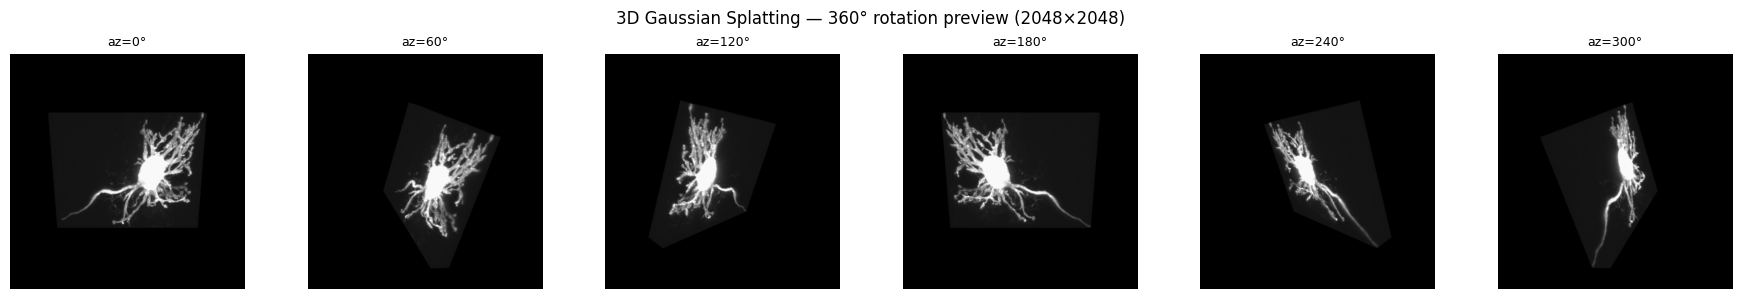

In [6]:
"""
Generate a 360° Y-axis rotation GIF of the 3D Gaussian Splatting model at 1028×1028.
"""
import imageio
from pathlib import Path

# ── Re-build camera at higher resolution ──
hi_res = 2048
camera_hi = Camera.from_config(cfg, width=hi_res, height=hi_res)
print(f"Camera: {hi_res}×{hi_res}, fx={camera_hi.fx:.1f}")

n_frames = 120
fps = 24
elevation = 15.0
out_path = Path("/workspace/end2endgs/e2e_rotate360_1028.gif")
out_path.parent.mkdir(parents=True, exist_ok=True)

frames = []
azimuths = np.linspace(0, 360, n_frames, endpoint=False)

print(f"Rendering {n_frames} frames at {hi_res}×{hi_res}, el={elevation}°, az=[0°..360°) ...")

with torch.no_grad():
    for i, az in enumerate(azimuths):
        R_cam, T_cam = _orbit_pose(elevation, float(az), radius)
        R_cam = R_cam.to(device)
        T_cam = T_cam.to(device)

        img, _ = render_mip_projection(
            gaussians, camera_hi, R_cam, T_cam,
            beta=beta, chunk_size=4096,
        )

        img_np = img.detach().cpu().numpy()
        img_np = np.clip(img_np / (img_np.max() + 1e-8), 0, 1)
        frame = (img_np * 255).astype(np.uint8)
        frames.append(frame)

        if (i + 1) % 30 == 0:
            print(f"  {i+1}/{n_frames} frames rendered")

print(f"All {n_frames} frames rendered. Saving GIF...")
imageio.mimsave(str(out_path), frames, fps=fps, loop=0)
print(f"GIF saved → {out_path}  ({out_path.stat().st_size / 1024:.0f} KB)")

# Preview strip
preview_idx = list(range(0, n_frames, n_frames // 6))
fig, axes = plt.subplots(1, len(preview_idx), figsize=(18, 3))
for j, idx in enumerate(preview_idx):
    axes[j].imshow(frames[idx], cmap="gray")
    axes[j].set_title(f"az={azimuths[idx]:.0f}°", fontsize=9)
    axes[j].axis("off")
fig.suptitle(f"3D Gaussian Splatting — 360° rotation preview ({hi_res}×{hi_res})", fontsize=12)
plt.tight_layout()
plt.show()


Loaded gsplat model: step 10000, K=50000
  Loaded 106 views, 813×647
Rendered 8 views


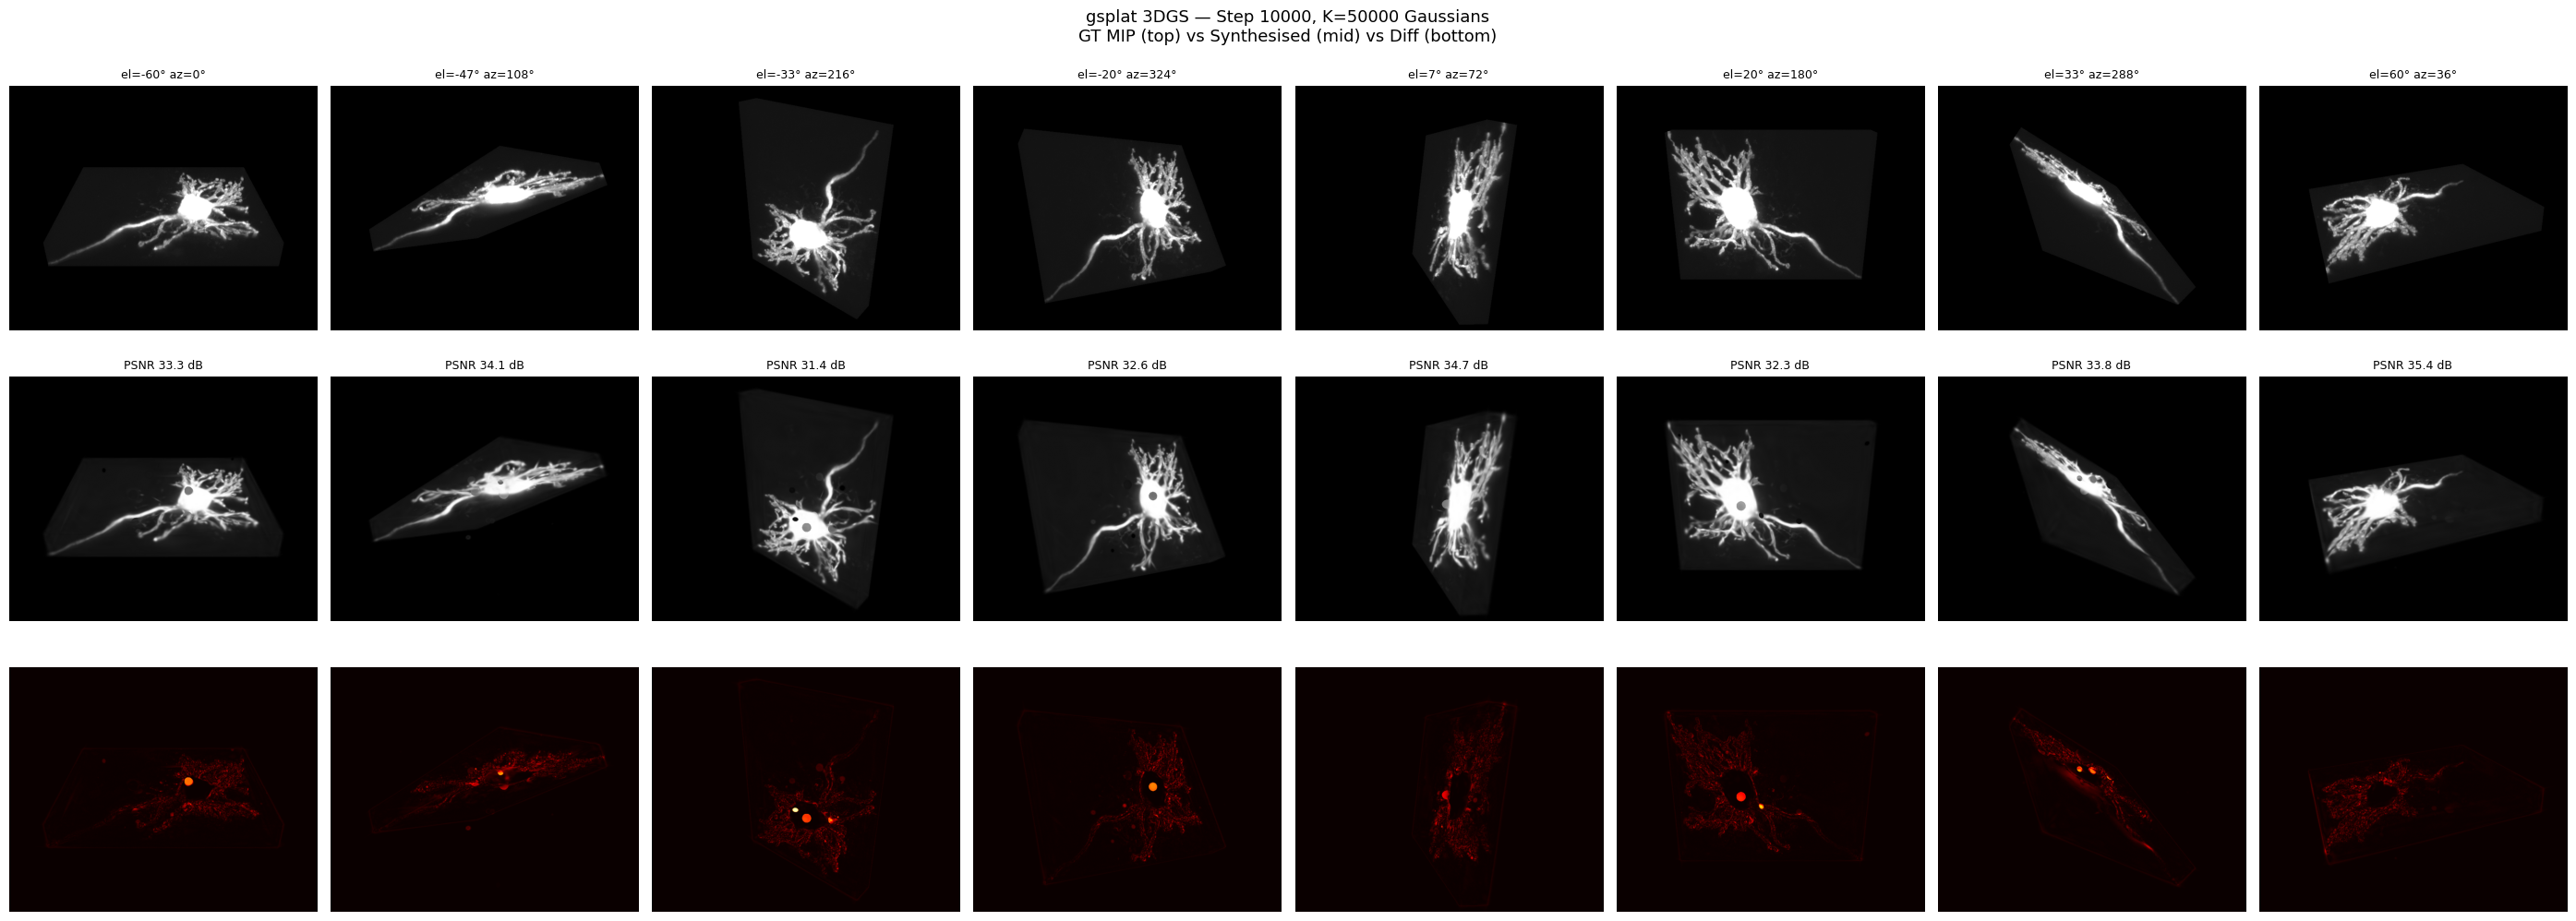

In [5]:
"""
Render synthesised frames from the gsplat-trained model at various viewpoints.
Uses gsplat.rasterization for differentiable rendering.
"""
import sys, os, json, math
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "/workspace/end2endgs")

import gsplat
from train_gsplat import GaussianModel, MIPDataset

# ── Load checkpoint ──
device = torch.device("cuda")
ckpt_path = "/workspace/end2endgs/checkpoints/gsplat_ckpt/gsplat_step10000.pt"
model, step = GaussianModel.from_checkpoint(ckpt_path, device)
print(f"Loaded gsplat model: step {step}, K={model.n}")

# ── Load dataset for cameras & GT images ──
dataset = MIPDataset("/workspace/end2endgs/gt_mip_dataset", device)

# ── Pick 8 diverse viewpoints (spread across the 106 views) ──
n_show = 8
indices = list(range(0, dataset.n_views, dataset.n_views // n_show))[:n_show]

# ── Render all selected views ──
synth_frames = []
gt_frames = []
view_labels = []

with open("/workspace/end2endgs/gt_mip_dataset/cameras.json") as f:
    meta = json.load(f)

with torch.no_grad():
    for idx in indices:
        frame_info = meta["frames"][idx]
        el, az = frame_info["elevation"], frame_info["azimuth"]
        view_labels.append(f"el={el:.0f}° az={az:.0f}°")

        viewmats, Ks, gt_imgs = dataset.get_batch([idx])
        renders, alphas, _ = gsplat.rasterization(
            means=model.means,
            quats=F.normalize(model.quats, dim=-1),
            scales=torch.exp(model.log_scales).clamp(1e-6, 1.0),
            opacities=torch.sigmoid(model.logit_opacities),
            colors=torch.sigmoid(model.log_colors),
            viewmats=viewmats,
            Ks=Ks,
            width=dataset.width,
            height=dataset.height,
            near_plane=dataset.near,
            far_plane=dataset.far,
            render_mode="RGB",
            packed=True,
            rasterize_mode="antialiased",
        )
        # renders: (1, H, W, 3), gt_imgs: (1, H, W)
        synth_np = renders[0, :, :, 0].cpu().numpy()  # take R channel (grayscale)
        gt_np = gt_imgs[0].cpu().numpy()

        synth_frames.append(synth_np / (synth_np.max() + 1e-8))
        gt_frames.append(gt_np / (gt_np.max() + 1e-8))

print(f"Rendered {n_show} views")

# ── Plot: GT vs Synthesised vs Diff ──
fig, axes = plt.subplots(3, n_show, figsize=(3.5 * n_show, 10.5))

for j in range(n_show):
    axes[0, j].imshow(gt_frames[j], cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(view_labels[j], fontsize=9)
    axes[0, j].axis("off")
    if j == 0:
        axes[0, j].set_ylabel("Ground Truth", fontsize=11, rotation=0, labelpad=70)

    axes[1, j].imshow(synth_frames[j], cmap="gray", vmin=0, vmax=1)
    axes[1, j].axis("off")
    if j == 0:
        axes[1, j].set_ylabel("gsplat (synth)", fontsize=11, rotation=0, labelpad=70)

    # PSNR per view
    mse = np.mean((synth_frames[j] - gt_frames[j]) ** 2)
    psnr = -10 * np.log10(mse + 1e-10)
    axes[1, j].set_title(f"PSNR {psnr:.1f} dB", fontsize=9)

    # Diff row: absolute difference
    diff = np.abs(gt_frames[j] - synth_frames[j])
    axes[2, j].imshow(diff, cmap="hot", vmin=0, vmax=1)
    axes[2, j].axis("off")
    if j == 0:
        axes[2, j].set_ylabel("Diff (|GT−synth|)", fontsize=11, rotation=0, labelpad=70)

fig.suptitle(f"gsplat 3DGS — Step {step}, K={model.n} Gaussians\nGT MIP (top) vs Synthesised (mid) vs Diff (bottom)", fontsize=13)
fig.savefig(f"./figure/gsplat_synth_vs_gt_step{step}_K{model.n}.png", dpi=300)
plt.tight_layout()
plt.show()

Loaded MIP model: epoch 2000, K=483952
Volume loaded: (100, 647, 813)


Rendered 8 views


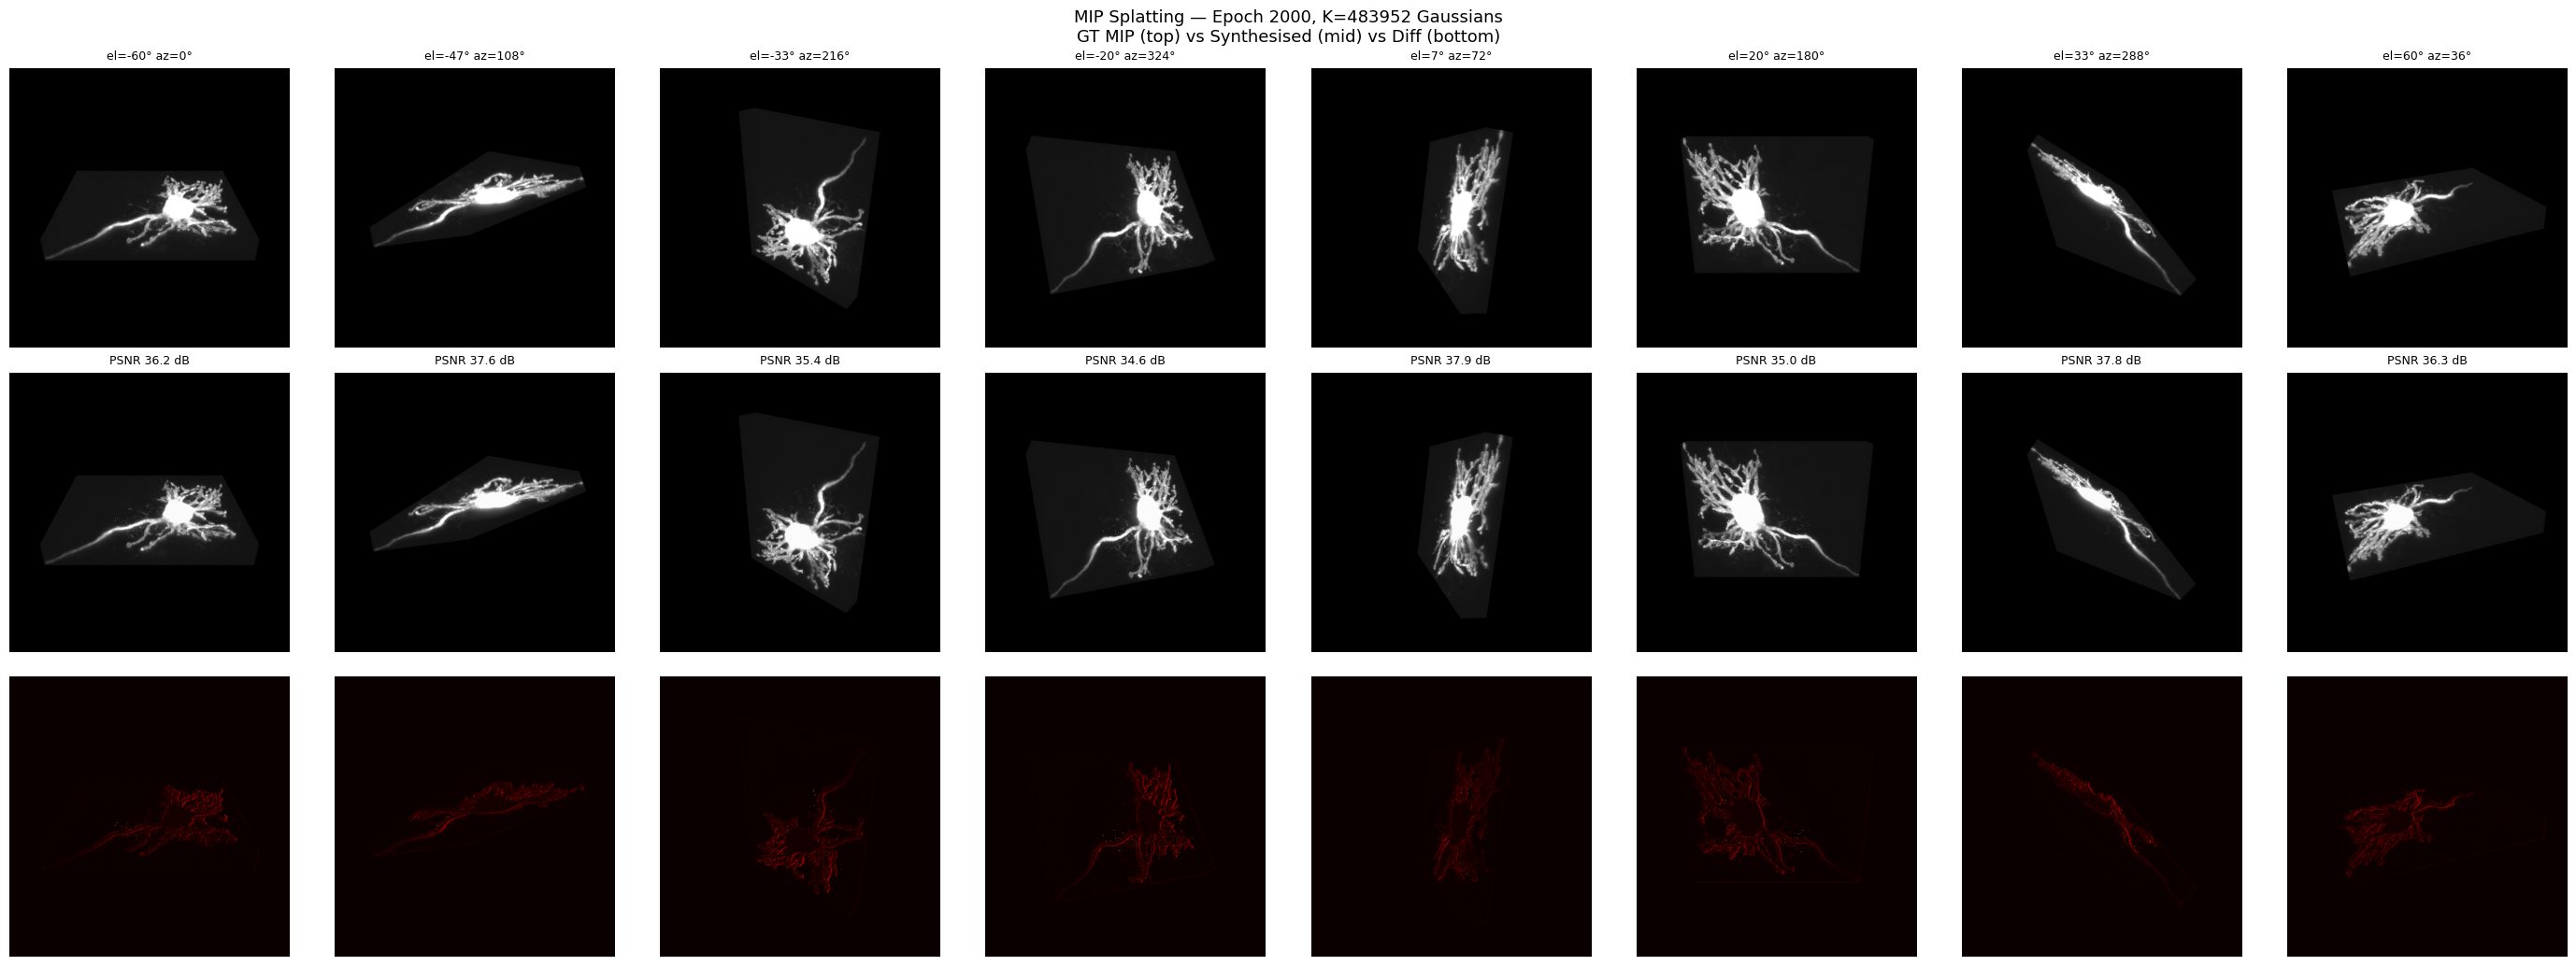

In [6]:
"""
Render synthesised frames from the MIP-splatting model at the same viewpoints.
Uses render_mip_projection (soft-MIP) and render_gt_mip (voxel-based GT).
"""
import sys, os, json, math
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "/workspace/end2endgs")

from rendering import (
    Camera, GaussianParameters,
    compute_aspect_scales, apply_aspect_correction,
    render_mip_projection, render_gt_mip,
    load_volume, load_config, _orbit_pose,
    psnr_metric,
)

# ── Load MIP checkpoint ──
device = torch.device("cuda")
mip_ckpt_path = "/workspace/end2endgs/checkpoints/mip_ckpt/splat_ep2000.pt"
checkpoint = torch.load(mip_ckpt_path, map_location=device)
epoch = checkpoint["epoch"]
means           = checkpoint["means"].to(device)
log_scales      = checkpoint["log_scales"].to(device)
quaternions     = checkpoint["quaternions"].to(device)
log_intensities = checkpoint["log_intensities"].to(device)
K_gauss = means.shape[0]
print(f"Loaded MIP model: epoch {epoch}, K={K_gauss}")

# ── Build covariances ──
scales = torch.exp(log_scales).clamp(1e-5, 1e2)
q = F.normalize(quaternions, p=2, dim=-1)
w, x, y, z = q[:, 0], q[:, 1], q[:, 2], q[:, 3]
R_mat = torch.zeros(K_gauss, 3, 3, device=device)
R_mat[:, 0, 0] = 1-2*(y*y+z*z);  R_mat[:, 0, 1] = 2*(x*y-w*z);  R_mat[:, 0, 2] = 2*(x*z+w*y)
R_mat[:, 1, 0] = 2*(x*y+w*z);    R_mat[:, 1, 1] = 1-2*(x*x+z*z); R_mat[:, 1, 2] = 2*(y*z-w*x)
R_mat[:, 2, 0] = 2*(x*z-w*y);    R_mat[:, 2, 1] = 2*(y*z+w*x);   R_mat[:, 2, 2] = 1-2*(x*x+y*y)
S2  = torch.diag_embed(scales ** 2)
cov = R_mat @ S2 @ R_mat.transpose(-2, -1)
intensities = torch.sigmoid(log_intensities)

# ── Camera & aspect correction ──
cfg = load_config("config_splat.yml")
vol_shape = (100, 647, 813)
aspect_scales = compute_aspect_scales(vol_shape).to(device)

gaussians = GaussianParameters(means=means, covariances=cov, intensities=intensities)
gaussians = apply_aspect_correction(gaussians, aspect_scales)

res = 512
camera = Camera.from_config(cfg, width=res, height=res)
beta = cfg["training"]["beta_mip"]
radius = cfg["poses"]["radius"]

# ── Load volume for GT MIP ──
vol_path = "/workspace/hisnegs/dataset/10-2900-control-cell-05_cropped_corrected.tif"
vol_np = load_volume(vol_path)
vol_gpu = torch.from_numpy(vol_np).float().to(device)
print(f"Volume loaded: {vol_np.shape}")

# ── Use same viewpoints as gsplat cell ──
with open("/workspace/end2endgs/gt_mip_dataset/cameras.json") as f:
    meta = json.load(f)

n_show = 8
n_views = len(meta["frames"])
indices = list(range(0, n_views, n_views // n_show))[:n_show]

# ── Render all selected views ──
synth_frames = []
gt_frames = []
view_labels = []

with torch.no_grad():
    for idx in indices:
        frame_info = meta["frames"][idx]
        el, az = frame_info["elevation"], frame_info["azimuth"]
        view_labels.append(f"el={el:.0f}° az={az:.0f}°")

        R_cam, T_cam = _orbit_pose(el, az, radius)
        R_cam, T_cam = R_cam.to(device), T_cam.to(device)

        # Synthesised (MIP splatting)
        img_synth, n_vis = render_mip_projection(
            gaussians, camera, R_cam, T_cam,
            beta=beta, chunk_size=4096,
        )
        # Ground truth (ray-marched volume MIP)
        img_gt = render_gt_mip(vol_gpu, camera, R_cam, T_cam)

        synth_np = img_synth.cpu().numpy()
        gt_np = img_gt.cpu().numpy()

        synth_frames.append(synth_np / (synth_np.max() + 1e-8))
        gt_frames.append(gt_np / (gt_np.max() + 1e-8))

print(f"Rendered {n_show} views")

# ── Plot: GT vs Synthesised vs Diff ──
fig, axes = plt.subplots(3, n_show, figsize=(3.5 * n_show, 10.5))

for j in range(n_show):
    axes[0, j].imshow(gt_frames[j], cmap="gray", vmin=0, vmax=1)
    axes[0, j].set_title(view_labels[j], fontsize=9)
    axes[0, j].axis("off")
    if j == 0:
        axes[0, j].set_ylabel("Ground Truth", fontsize=11, rotation=0, labelpad=70)

    axes[1, j].imshow(synth_frames[j], cmap="gray", vmin=0, vmax=1)
    axes[1, j].axis("off")
    if j == 0:
        axes[1, j].set_ylabel("MIP (synth)", fontsize=11, rotation=0, labelpad=70)

    # PSNR per view
    mse = np.mean((synth_frames[j] - gt_frames[j]) ** 2)
    psnr = -10 * np.log10(mse + 1e-10)
    axes[1, j].set_title(f"PSNR {psnr:.1f} dB", fontsize=9)

    # Diff row: absolute difference
    diff = np.abs(gt_frames[j] - synth_frames[j])
    axes[2, j].imshow(diff, cmap="hot", vmin=0, vmax=1)
    axes[2, j].axis("off")
    if j == 0:
        axes[2, j].set_ylabel("Diff (|GT−synth|)", fontsize=11, rotation=0, labelpad=70)

fig.suptitle(f"MIP Splatting — Epoch {epoch}, K={K_gauss} Gaussians\nGT MIP (top) vs Synthesised (mid) vs Diff (bottom)", fontsize=13)
fig.savefig(f"./figure/mip_splatting_epoch{epoch}_K{K_gauss}.png", dpi=300)
plt.tight_layout()
plt.show()

  Loaded 106 views, 813×647
Saved figure/gsplat_comparison.png
Saved figure/mip_splatting_comparison.png


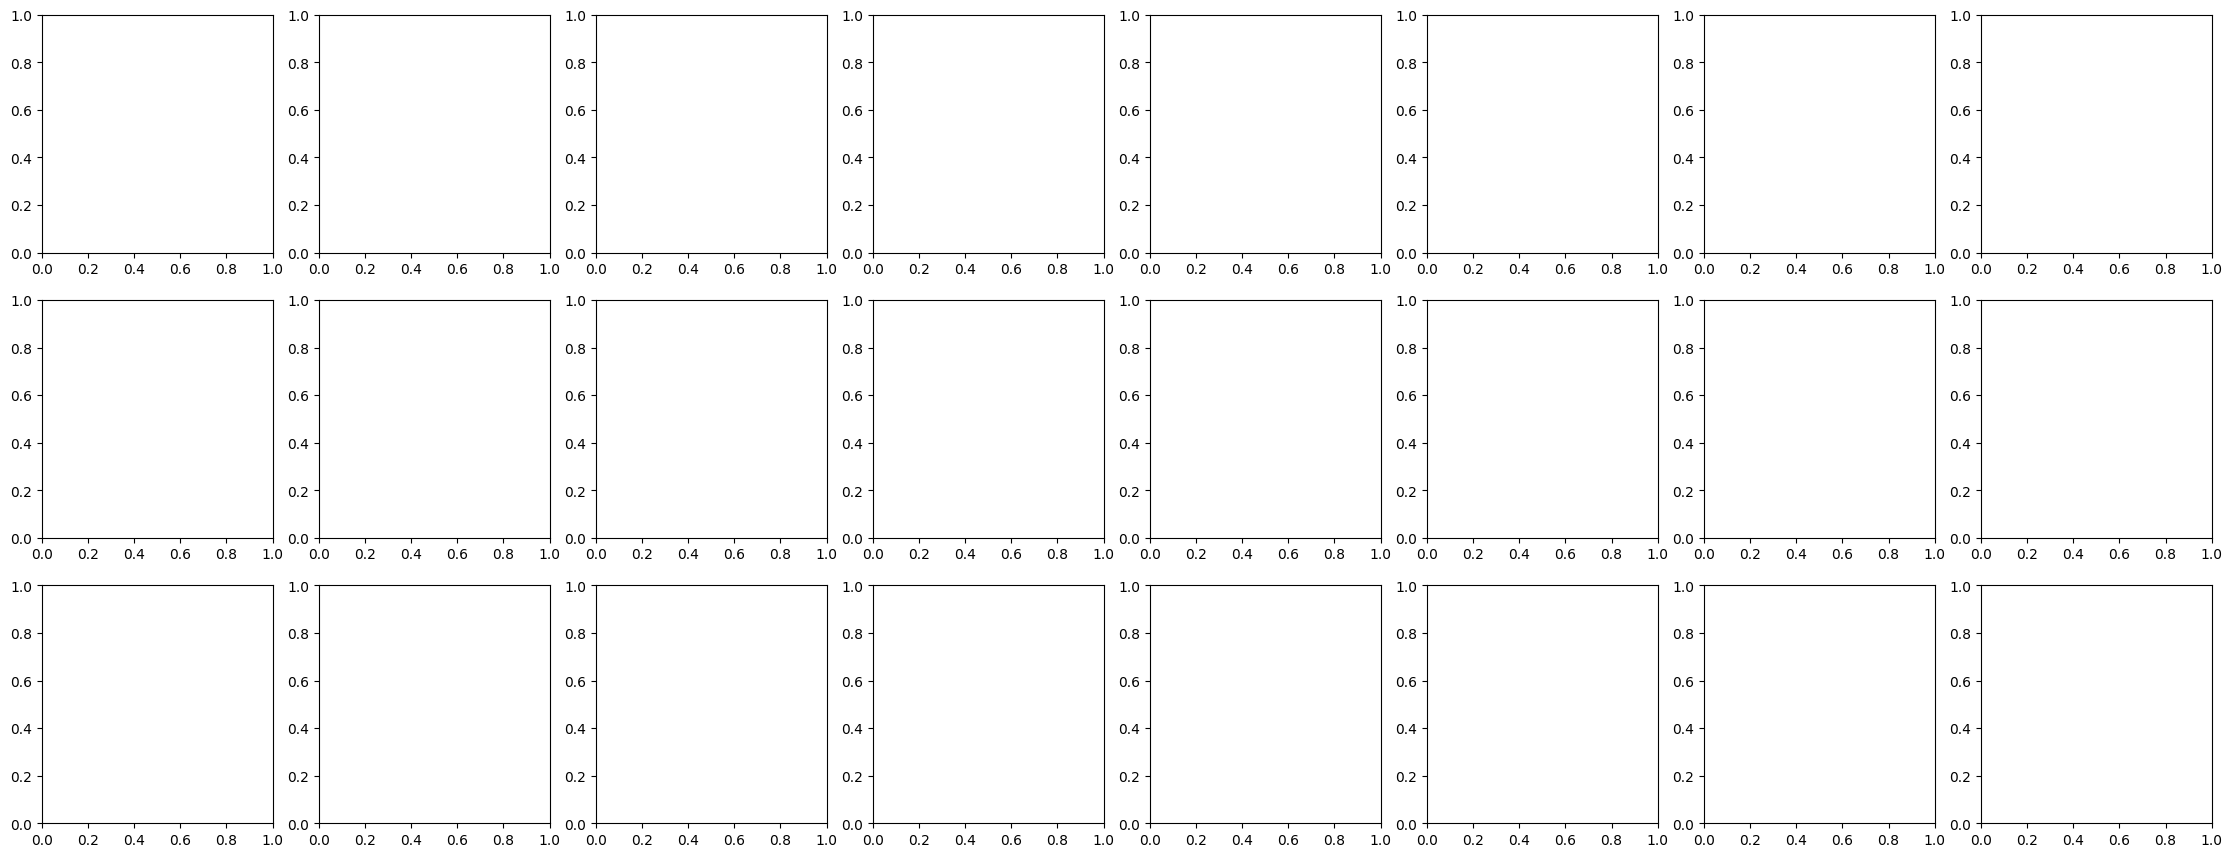

In [4]:
# Save both comparison figures to figure/
import os
os.makedirs("/workspace/end2endgs/figure", exist_ok=True)

# Re-create and save gsplat figure
fig1, axes1 = plt.subplots(3, n_show, figsize=(3.5 * n_show, 10.5))
# Need to reload gsplat data from Cell 4 variables — use kernel state
# We'll just re-import and re-run the plotting from the already-computed frames

# ── gsplat figure (from Cell 4 kernel state) ──
# Re-render using the existing gsplat variables
import json
import gsplat as _gsplat
from train_gsplat import GaussianModel as _GM, MIPDataset as _MD

_device = torch.device("cuda")
_ckpt_path = "/workspace/end2endgs/checkpoints/gsplat_ckpt/gsplat_step10000.pt"
_model, _step = _GM.from_checkpoint(_ckpt_path, _device)
_dataset = _MD("/workspace/end2endgs/gt_mip_dataset", _device)

_n_show = 8
_indices = list(range(0, _dataset.n_views, _dataset.n_views // _n_show))[:_n_show]

with open("/workspace/end2endgs/gt_mip_dataset/cameras.json") as f:
    _meta = json.load(f)

_synth, _gt, _labels = [], [], []
with torch.no_grad():
    for _idx in _indices:
        _fi = _meta["frames"][_idx]
        _labels.append(f"el={_fi['elevation']:.0f}° az={_fi['azimuth']:.0f}°")
        _vm, _K, _gi = _dataset.get_batch([_idx])
        _r, _a, _ = _gsplat.rasterization(
            means=_model.means, quats=F.normalize(_model.quats, dim=-1),
            scales=torch.exp(_model.log_scales).clamp(1e-6, 1.0),
            opacities=torch.sigmoid(_model.logit_opacities),
            colors=torch.sigmoid(_model.log_colors),
            viewmats=_vm, Ks=_K, width=_dataset.width, height=_dataset.height,
            near_plane=_dataset.near, far_plane=_dataset.far,
            render_mode="RGB", packed=True, rasterize_mode="antialiased",
        )
        _s = _r[0,:,:,0].cpu().numpy(); _g = _gi[0].cpu().numpy()
        _synth.append(_s / (_s.max() + 1e-8)); _gt.append(_g / (_g.max() + 1e-8))

fig1, ax1 = plt.subplots(3, _n_show, figsize=(3.5 * _n_show, 10.5))
for j in range(_n_show):
    ax1[0,j].imshow(_gt[j], cmap="gray", vmin=0, vmax=1); ax1[0,j].set_title(_labels[j], fontsize=9); ax1[0,j].axis("off")
    if j==0: ax1[0,j].set_ylabel("Ground Truth", fontsize=11, rotation=0, labelpad=70)
    ax1[1,j].imshow(_synth[j], cmap="gray", vmin=0, vmax=1); ax1[1,j].axis("off")
    if j==0: ax1[1,j].set_ylabel("gsplat (synth)", fontsize=11, rotation=0, labelpad=70)
    _mse = np.mean((_synth[j]-_gt[j])**2); _psnr = -10*np.log10(_mse+1e-10)
    ax1[1,j].set_title(f"PSNR {_psnr:.1f} dB", fontsize=9)
    _d = np.abs(_gt[j]-_synth[j]); ax1[2,j].imshow(_d, cmap="hot", vmin=0, vmax=1); ax1[2,j].axis("off")
    if j==0: ax1[2,j].set_ylabel("Diff (|GT−synth|)", fontsize=11, rotation=0, labelpad=70)
fig1.suptitle(f"gsplat 3DGS — Step {_step}, K={_model.n} Gaussians\nGT MIP (top) vs Synthesised (mid) vs Diff (bottom)", fontsize=13)
fig1.tight_layout()
fig1.savefig("/workspace/end2endgs/figure/gsplat_comparison.png", dpi=150, bbox_inches="tight")
print("Saved figure/gsplat_comparison.png")
plt.close(fig1)

# ── MIP splatting figure (from Cell 5 kernel state) ──
from rendering import (Camera, GaussianParameters, compute_aspect_scales,
    apply_aspect_correction, render_mip_projection, render_gt_mip,
    load_volume, load_config, _orbit_pose)

_mip_ckpt = torch.load("/workspace/end2endgs/checkpoints/mip_ckpt/splat_ep2000.pt", map_location=_device)
_epoch = _mip_ckpt["epoch"]
_means = _mip_ckpt["means"].to(_device)
_ls = _mip_ckpt["log_scales"].to(_device)
_quat = _mip_ckpt["quaternions"].to(_device)
_li = _mip_ckpt["log_intensities"].to(_device)
_Kg = _means.shape[0]

_sc = torch.exp(_ls).clamp(1e-5, 1e2)
_q = F.normalize(_quat, p=2, dim=-1)
_w,_x,_y,_z = _q[:,0],_q[:,1],_q[:,2],_q[:,3]
_R = torch.zeros(_Kg,3,3,device=_device)
_R[:,0,0]=1-2*(_y*_y+_z*_z); _R[:,0,1]=2*(_x*_y-_w*_z); _R[:,0,2]=2*(_x*_z+_w*_y)
_R[:,1,0]=2*(_x*_y+_w*_z); _R[:,1,1]=1-2*(_x*_x+_z*_z); _R[:,1,2]=2*(_y*_z-_w*_x)
_R[:,2,0]=2*(_x*_z-_w*_y); _R[:,2,1]=2*(_y*_z+_w*_x); _R[:,2,2]=1-2*(_x*_x+_y*_y)
_S2 = torch.diag_embed(_sc**2)
_cov = _R @ _S2 @ _R.transpose(-2,-1)
_ints = torch.sigmoid(_li)

_cfg = load_config("config_splat.yml")
_asp = compute_aspect_scales((100,647,813)).to(_device)
_gauss = GaussianParameters(means=_means, covariances=_cov, intensities=_ints)
_gauss = apply_aspect_correction(_gauss, _asp)
_cam = Camera.from_config(_cfg, width=512, height=512)
_beta = _cfg["training"]["beta_mip"]; _rad = _cfg["poses"]["radius"]

_vol = load_volume("/workspace/hisnegs/dataset/10-2900-control-cell-05_cropped_corrected.tif")
_vg = torch.from_numpy(_vol).float().to(_device)

_ms, _mg, _ml = [], [], []
with torch.no_grad():
    for _idx in _indices:
        _fi = _meta["frames"][_idx]
        _ml.append(f"el={_fi['elevation']:.0f}° az={_fi['azimuth']:.0f}°")
        _Rc,_Tc = _orbit_pose(_fi['elevation'], _fi['azimuth'], _rad)
        _Rc,_Tc = _Rc.to(_device), _Tc.to(_device)
        _is, _ = render_mip_projection(_gauss, _cam, _Rc, _Tc, beta=_beta, chunk_size=4096)
        _ig = render_gt_mip(_vg, _cam, _Rc, _Tc)
        _sn = _is.cpu().numpy(); _gn = _ig.cpu().numpy()
        _ms.append(_sn/(_sn.max()+1e-8)); _mg.append(_gn/(_gn.max()+1e-8))

fig2, ax2 = plt.subplots(3, _n_show, figsize=(3.5*_n_show, 10.5))
for j in range(_n_show):
    ax2[0,j].imshow(_mg[j], cmap="gray", vmin=0, vmax=1); ax2[0,j].set_title(_ml[j], fontsize=9); ax2[0,j].axis("off")
    if j==0: ax2[0,j].set_ylabel("Ground Truth", fontsize=11, rotation=0, labelpad=70)
    ax2[1,j].imshow(_ms[j], cmap="gray", vmin=0, vmax=1); ax2[1,j].axis("off")
    if j==0: ax2[1,j].set_ylabel("MIP (synth)", fontsize=11, rotation=0, labelpad=70)
    _mse = np.mean((_ms[j]-_mg[j])**2); _psnr = -10*np.log10(_mse+1e-10)
    ax2[1,j].set_title(f"PSNR {_psnr:.1f} dB", fontsize=9)
    _d = np.abs(_mg[j]-_ms[j]); ax2[2,j].imshow(_d, cmap="hot", vmin=0, vmax=1); ax2[2,j].axis("off")
    if j==0: ax2[2,j].set_ylabel("Diff (|GT−synth|)", fontsize=11, rotation=0, labelpad=70)
fig2.suptitle(f"MIP Splatting — Epoch {_epoch}, K={_Kg} Gaussians\nGT MIP (top) vs Synthesised (mid) vs Diff (bottom)", fontsize=13)
fig2.tight_layout()
fig2.savefig("/workspace/end2endgs/figure/mip_splatting_comparison.png", dpi=150, bbox_inches="tight")
print("Saved figure/mip_splatting_comparison.png")
plt.close(fig2)